In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
df = files.upload()

Saving churn-bigml-80.csv to churn-bigml-80.csv
Saving churn-bigml-20.csv to churn-bigml-20.csv


In [ ]:
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

In [ ]:
print(train_df.head())
print(train_df.info())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [ ]:
train_df['Churn'].value_counts()

,count
Churn,
False,2278
True,388


In [ ]:
train_df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [ ]:
# Encode kolom biner (Yes/No -> 1/0)
for df in [train_df, test_df]:
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)

# One-hot encoding untuk kolom State (karena banyak kategori, bukan cuma 2)
train_df = pd.get_dummies(train_df, columns=['State'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['State'], drop_first=True)

# Samakan kolom antara train dan test (jaga-jaga kalau ada State yang cuma muncul di salah satu)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

In [ ]:
train_df.shape

(2666, 69)

In [ ]:
test_df.shape

(667, 69)

In [ ]:
train_df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,0,1,25,265.1,110,45.07,197.4,99,...,False,False,False,False,False,False,False,False,False,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,...,False,False,False,False,False,False,False,False,False,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,...,False,False,False,False,False,False,False,False,False,False
3,84,408,1,0,0,299.4,71,50.90,61.9,88,...,False,False,False,False,False,False,False,False,False,False
4,75,415,1,0,0,166.7,113,28.34,148.3,122,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8590704647676162

Confusion Matrix:
[[549  23]
 [ 71  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       572
           1       0.51      0.25      0.34        95

    accuracy                           0.86       667
   macro avg       0.70      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



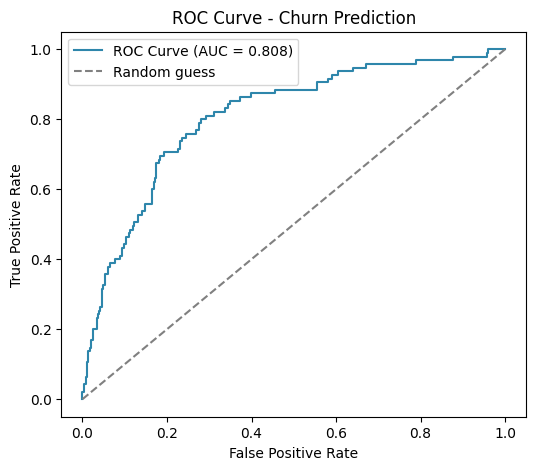

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probabilitas kelas churn=1

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})", color="#2E86AB")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend()
plt.show()

In [ ]:
import numpy as np

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(10))

                   Feature  Coefficient  Odds Ratio
3          Voice mail plan    -0.854750    0.425390
17  Customer service calls     0.712090    2.038246
2       International plan     0.682279    1.978381
4    Number vmail messages     0.450988    1.569862
7         Total day charge     0.357277    1.429432
5        Total day minutes     0.357197    1.429318
15        Total intl calls    -0.297525    0.742654
60                State_TX     0.213600    1.238128
57                State_SC     0.194321    1.214487
43                State_MT     0.185263    1.203535


## Conclusion

A Logistic Regression model was trained on the Telecom Churn dataset (2666 training samples, 667 test samples) to predict whether a customer would churn, using 69 features (including one-hot encoded state and encoded categorical variables).

The model achieved 85.9% accuracy and an AUC of 0.808. However, accuracy alone was misleading here because the dataset is **imbalanced** — 85.5% of customers did not churn, so a model that always predicted "no churn" would already score ~85.5% accuracy without learning anything meaningful.

Looking at the confusion matrix and classification report revealed the real picture: **recall for the churn class was only 25%**, meaning the model missed 71 out of 95 customers who actually churned. This happened because the model, trained on mostly "no churn" examples, tends to assign lower churn probabilities overall — and with the default 0.5 decision threshold, many genuinely at-risk customers fell just below that cutoff and were classified as "not churning."

The AUC of 0.808, however, showed the model **does have good discriminative ability** — it generally assigns higher churn probabilities to customers who actually churn. This suggests the issue isn't the model's underlying signal, but rather the fixed 0.5 threshold being poorly suited to imbalanced data.

Interpreting the coefficients (via odds ratios) showed that:
- **Customer service calls** was the strongest churn driver (odds ratio ≈ 2.04) — customers who call support more often are more likely to leave
- **International plan** subscribers were also more likely to churn (odds ratio ≈ 1.98)
- **Voice mail plan** subscribers were less likely to churn (odds ratio ≈ 0.43), suggesting they may be more engaged/loyal customers

**Key takeaway:** For imbalanced classification problems like churn prediction, accuracy alone is not a reliable metric. Recall, precision, and AUC give a more honest picture of model performance, and techniques like adjusting the decision threshold or using `class_weight='balanced'` could help the model catch more at-risk customers — an important next step for a real-world churn prevention use case.